# Procesamiento de Imágenes con la Transformada Rápida de Fourier (FFT)

**Universidad Centroamericana "José Simeón Cañas"**  
Facultad de Ingeniería y Arquitectura — Departamento de Matemática  
Análisis Numérico · Ciclo 01-2026  

---

## Descripción general

En este notebook se explora la aplicación de la **Transformada Discreta de Fourier (DFT)** 
en dos dimensiones para el procesamiento digital de imágenes. 
Específicamente, se estudia cómo el **filtrado en el dominio de la frecuencia** permite 
eliminar ruido de una imagen utilizando un filtro gaussiano paso-bajo.

El flujo de trabajo seguido es el siguiente:

1. Carga y preprocesamiento de la imagen.
2. Adición de ruido gaussiano sintético.
3. Cálculo de la FFT 2D.
4. Construcción y aplicación de un filtro gaussiano en el dominio frecuencial.
5. Reconstrucción mediante la IFFT 2D.
6. Análisis comparativo de resultados.


---
## 1. Marco Teórico

### 1.1 Transformada Discreta de Fourier en 2D

Para una imagen discreta $f[m, n]$ de tamaño $M \times N$, la **DFT 2D** se define como:

$$
F[u, v] = \sum_{m=0}^{M-1} \sum_{n=0}^{N-1} f[m,n]\, e^{-j2\pi\left(\frac{um}{M} + \frac{vn}{N}\right)}
$$

donde $u \in \{0,\dots,M-1\}$ y $v \in \{0,\dots,N-1\}$ son las frecuencias espaciales discretas. 
Cada coeficiente $F[u,v]$ es un número complejo cuya **magnitud** representa la energía en esa frecuencia 
y cuya **fase** codifica la posición espacial de esa componente.

### 1.2 Transformada Inversa (IDFT 2D)

La imagen original se recupera mediante la transformada inversa:

$$
f[m, n] = \frac{1}{MN} \sum_{u=0}^{M-1} \sum_{v=0}^{N-1} F[u,v]\, e^{j2\pi\left(\frac{um}{M} + \frac{vn}{N}\right)}
$$

### 1.3 Desplazamiento del espectro ()

Por convención, la FFT coloca las frecuencias bajas en las esquinas de la matriz. 
La operación **fftshift** reordena el espectro para centrar las frecuencias bajas, 
lo que facilita la visualización y el diseño de filtros radiales:

$$
F_{\text{shift}}[u, v] = F\left[\left(u + \frac{M}{2}\right) \bmod M,\; \left(v + \frac{N}{2}\right) \bmod N\right]
$$

### 1.4 Filtro Gaussiano Paso-Bajo

Un filtro paso-bajo atenúa las frecuencias altas (bordes, ruido) y preserva las bajas (estructura global). 
El filtro gaussiano en el dominio de la frecuencia se define como:

$$
H[u, v] = e^{-\dfrac{(u - u_0)^2 + (v - v_0)^2}{2\sigma^2}}
$$

donde $(u_0, v_0)$ es el centro del espectro y $\sigma$ controla el **ancho de banda**: 
un $\sigma$ pequeño elimina más frecuencias (imagen más suave), 
un $\sigma$ grande conserva más detalle.

El espectro filtrado se obtiene mediante multiplicación punto a punto:

$$
G[u, v] = F_{\text{shift}}[u, v] \cdot H[u, v]
$$


---
## 2. Configuración del Entorno

Se importan las bibliotecas necesarias:
- **NumPy**: operaciones numéricas y módulo .
- **Matplotlib**: visualización de imágenes y espectros.
- **PIL (Pillow)**: carga y conversión de imágenes.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print("Todo funciona")

Todo funciona


---
## 3. Carga y Preprocesamiento de la Imagen

La imagen se convierte a **escala de grises** para trabajar con una matriz 2D $f[m, n] \in \mathbb{R}^{M \times N}$, 
donde cada elemento representa la intensidad luminosa del píxel en el rango $[0, 255]$. 
Se redimensiona a $512 \times 512$ para uniformar el tamaño y facilitar los cálculos.


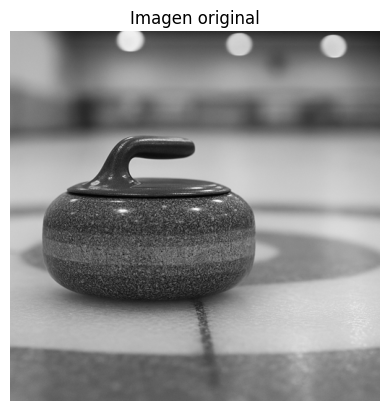

Tamaño: (512, 512)


In [2]:
# Cargar imagen en escala de grises
img = Image.open("imagenes/imagen1.png").convert("L")

# Reducir tamaño (clave para velocidad)
img = img.resize((512, 512))

# Convertir a matriz
img = np.array(img)

# Mostrar
plt.imshow(img, cmap='gray')
plt.title("Imagen original")
plt.axis('off')
plt.show()

# Ver tamaño (debug)
print("Tamaño:", img.shape)

---
## 4. Adición de Ruido Gaussiano

Se añade **ruido blanco gaussiano** a la imagen original para simular degradación. 
El ruido $\eta[m,n]$ sigue una distribución normal:

$$
\eta[m,n] \sim \mathcal{N}(\mu,\, \sigma^2) \quad \text{con } \mu = 0,\ \sigma = 100
$$

La imagen degradada resulta: $f_{\text{ruido}}[m,n] = f[m,n] + \eta[m,n]$

En el dominio de la frecuencia, el ruido blanco se distribuye de forma uniforme en todas las frecuencias, 
lo que lo hace separable del contenido de la imagen (concentrado en frecuencias bajas).


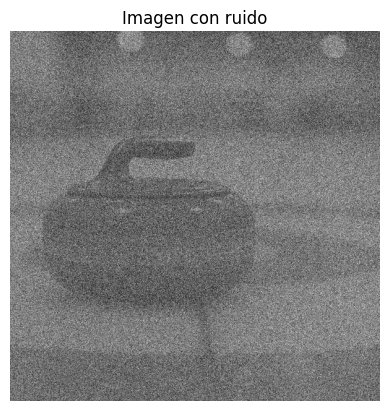

In [3]:
# Crear ruido gaussiano
noise = np.random.normal(0, 100, img.shape)

# Sumar ruido
img_ruido = img + noise

# Mostrar
plt.imshow(img_ruido, cmap='gray')
plt.title("Imagen con ruido")
plt.axis('off')
plt.show()

---
## 5. Cálculo de la FFT 2D

Se aplica  que implementa el algoritmo **Cooley-Tukey** con complejidad $O(MN \log MN)$, 
significativamente más eficiente que la DFT directa ($O(M^2 N^2)$). 
Luego se aplica  para centrar las frecuencias bajas $(u=0, v=0)$ en el centro de la matriz.


In [4]:
# FFT 2D
F = np.fft.fft2(img_ruido)

# Centrar frecuencias
F_shift = np.fft.fftshift(F)

print("FFT lista ✅")

FFT lista ✅


---
## 6. Visualización del Espectro de Frecuencias

El espectro se visualiza usando la **magnitud en escala logarítmica** para comprimir el rango dinámico 
(los coeficientes centrales son órdenes de magnitud más grandes que los periféricos):

$$
\text{Espectro}[u,v] = \log\bigl(|F_{\text{shift}}[u,v]| + 1\bigr)
$$

El punto brillante central corresponde a la componente DC ($F[0,0]$), 
proporcional a la suma total de intensidades de la imagen. 
Las frecuencias altas (bordes y ruido) se distribuyen hacia la periferia.


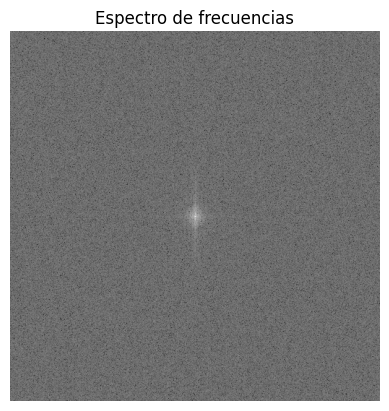

In [5]:
# Magnitud del espectro
magnitude = np.log(np.abs(F_shift) + 1)

# Mostrar
plt.imshow(magnitude, cmap='gray')
plt.title("Espectro de frecuencias")
plt.axis('off')
plt.show()

---
## 7. Construcción del Filtro Gaussiano Paso-Bajo

Se construye la máscara $H[u,v]$ centrada en $(u_0, v_0) = (M/2, N/2)$:

$$
H[u, v] = \exp\!\left(-\frac{(u - u_0)^2 + (v - v_0)^2}{2\sigma^2}\right)
$$

con $\sigma = 30$ píxeles en el dominio frecuencial. 
Valores de $H$ cercanos a 1 (zona central) conservan las frecuencias bajas; 
valores cercanos a 0 (zona periférica) eliminan las frecuencias altas correspondientes al ruido.


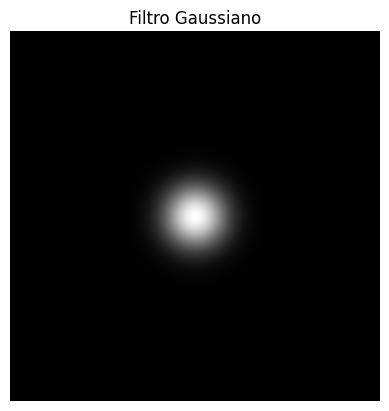

In [6]:
rows, cols = img.shape
crow, ccol = rows // 2, cols // 2

# Forma rápida (sin matrices gigantes)
Y, X = np.ogrid[:rows, :cols]

# Parámetro de reconstrucción
sigma = 30

# Filtro gaussiano
gaussian_filter = np.exp(-((X - ccol)**2 + (Y - crow)**2) / (2 * sigma**2))

# Ver filtro (opcional pero PRO)
plt.imshow(gaussian_filter, cmap='gray')
plt.title("Filtro Gaussiano")
plt.axis('off')
plt.show()


---
## 8. Aplicación del Filtro

El filtrado en frecuencia es equivalente a una **convolución en el dominio espacial** (Teorema de Convolución):

$$
g[m,n] = f_{\text{ruido}}[m,n] * h[m,n] \;\iff\; G[u,v] = F_{\text{shift}}[u,v] \cdot H[u,v]
$$

La multiplicación punto a punto en frecuencia es computacionalmente mucho más eficiente que la convolución espacial directa.


In [7]:
F_filtrado = F_shift * gaussian_filter

print("Filtro aplicado ✅")

Filtro aplicado ✅


---
## 9. Reconstrucción con la IFFT 2D

Se invierte el proceso: primero se deshace el centrado con , 
luego se aplica la transformada inversa  para regresar al dominio espacial:

$$
g[m,n] = \mathcal{F}^{-1}\bigl\{G[u,v]\bigr\} = \frac{1}{MN}\sum_{u}\sum_{v} G[u,v]\,e^{j2\pi\left(\frac{um}{M}+\frac{vn}{N}\right)}
$$

Se toma la **magnitud** del resultado complejo, ya que pequeños errores numéricos 
pueden introducir partes imaginarias residuales.


In [8]:
# Regresar al dominio espacial
F_ishift = np.fft.ifftshift(F_filtrado)
img_filtrada = np.fft.ifft2(F_ishift)

# Magnitud final
img_filtrada = np.abs(img_filtrada)

print("Imagen reconstruida ✅")

Imagen reconstruida ✅


---
## 10. Resultado: Imagen Filtrada

Visualización de la imagen reconstruida tras el filtrado gaussiano en frecuencia.


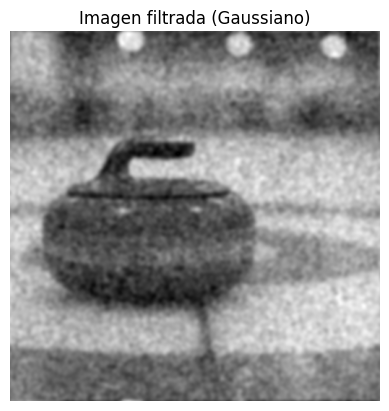

In [9]:
plt.imshow(img_filtrada, cmap='gray')
plt.title("Imagen filtrada (Gaussiano)")
plt.axis('off')
plt.show()

---
## 11. Comparación Final

Se presentan las tres etapas del proceso lado a lado para evaluar visualmente 
la efectividad del filtro gaussiano en la eliminación del ruido.


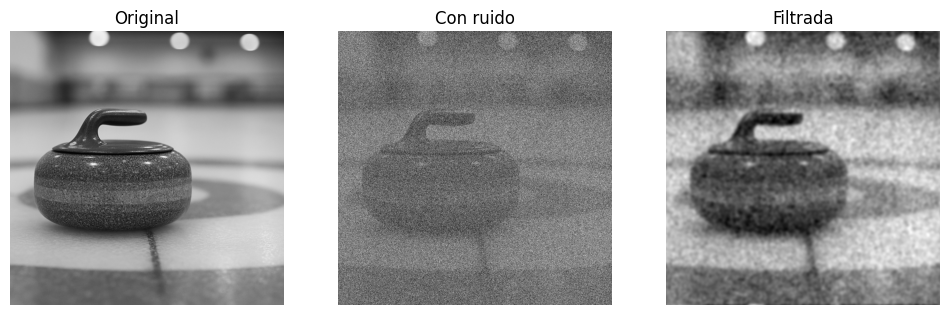

In [10]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img_ruido, cmap='gray')
plt.title("Con ruido")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(img_filtrada, cmap='gray')
plt.title("Filtrada")
plt.axis('off')

plt.show()

---
## 12. Experimento: Efecto del Parámetro $\sigma$

Se varía $\sigma \in \{10, 30, 60, 100\}$ para analizar el compromiso entre **eliminación de ruido** y **preservación de detalle**:

- $\sigma$ pequeño → filtro estrecho → alta suavización (posible pérdida de bordes).
- $\sigma$ grande → filtro ancho → conserva más detalle pero elimina menos ruido.


In [ ]:
sigmas = [10, 30, 60, 100]

# FFT de la imagen con ruido (base para todos los experimentos)
F = np.fft.fft2(img_ruido)
F_shift = np.fft.fftshift(F)

rows, cols = img.shape
crow, ccol = rows // 2, cols // 2
Y, X = np.ogrid[:rows, :cols]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for i, sigma in enumerate(sigmas):
    # Construir filtro gaussiano con el sigma actual
    H = np.exp(-((X - ccol)**2 + (Y - crow)**2) / (2 * sigma**2))

    # Aplicar filtro y reconstruir
    G = F_shift * H
    img_rec = np.abs(np.fft.ifft2(np.fft.ifftshift(G)))

    # Fila superior: filtro en frecuencia
    axes[0, i].imshow(H, cmap='gray')
    axes[0, i].set_title(f'Filtro H  ($\sigma={sigma}$)', fontsize=11)
    axes[0, i].axis('off')

    # Fila inferior: imagen reconstruida
    axes[1, i].imshow(img_rec, cmap='gray')
    axes[1, i].set_title(f'Imagen filtrada ($\sigma={sigma}$)', fontsize=11)
    axes[1, i].axis('off')

plt.suptitle('Efecto del parámetro $\sigma$ en el filtro gaussiano paso-bajo', fontsize=13)
plt.tight_layout()
plt.show()


---
## 13. Análisis Cuantitativo: Error Cuadrático Medio (MSE)

Para evaluar objetivamente la calidad del filtrado se calcula el **Error Cuadrático Medio** 
entre la imagen filtrada y la imagen original limpia:

$$
\text{MSE}(\sigma) = \frac{1}{MN} \sum_{m=0}^{M-1}\sum_{n=0}^{N-1} \bigl(f[m,n] - g_\sigma[m,n]\bigr)^2
$$

Un MSE menor indica que la imagen reconstruida es más fiel a la original.


In [ ]:
mse_values = []

for sigma in sigmas:
    H = np.exp(-((X - ccol)**2 + (Y - crow)**2) / (2 * sigma**2))
    G = F_shift * H
    img_rec = np.abs(np.fft.ifft2(np.fft.ifftshift(G)))
    mse = np.mean((img.astype(float) - img_rec)**2)
    mse_values.append(mse)
    print(f"sigma = {sigma:>4d} | MSE = {mse:.4f}")

# Gráfica de MSE vs sigma
plt.figure(figsize=(7, 4))
plt.plot(sigmas, mse_values, marker='o', color='royalblue', linewidth=2)
plt.xlabel(r'$\sigma$ (ancho de banda del filtro)', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title(r'Error Cuadrático Medio vs $\sigma$', fontsize=13)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


---
## 14. Conclusiones

1. **La FFT 2D permite filtrar eficientemente en el dominio de la frecuencia.** 
Gracias al algoritmo Cooley-Tukey, la complejidad se reduce de $O(M^2N^2)$ a $O(MN\log MN)$, 
haciendo el proceso viable incluso para imágenes de alta resolución.

2. **El filtro gaussiano paso-bajo atenúa el ruido blanco preservando la estructura global.** 
El ruido, al distribuirse uniformemente en todas las frecuencias, es suprimido 
por el decaimiento gaussiano que penaliza las frecuencias altas.

3. **El parámetro $\sigma$ establece un compromiso entre suavización y detalle.** 
Los experimentos muestran que $\sigma$ muy pequeño difumina la imagen en exceso, 
mientras que $\sigma$ grande conserva ruido residual. 
El valor óptimo depende del nivel de ruido y los requisitos de la aplicación.

4. **El Teorema de Convolución simplifica el diseño de filtros.** 
La multiplicación punto a punto en frecuencia equivale a una convolución espacial, 
lo que permite diseñar filtros sofisticados de manera intuitiva en el dominio frecuencial.

---
*Notebook elaborado con ,  y .*
